In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
from pathlib import Path
import pickle

import numpy as np
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
sns.set_context("talk", font_scale=1.4)

In [4]:
eois_path = "outputs/trf_eois/eois.csv"
clusters_path = "/userdata/jgauthier/projects/big-trf/cluster_data-word.pkl"
unique_variance_path = "/userdata/jgauthier/projects/ideal-word-representations/outputs/encoder_unique_variance/timit-no_repeats/baseline"

In [5]:
uv_df = pd.concat({subject.name: pd.read_csv(f"{unique_variance_path}/{subject.name}/unique_variance.csv")
                   for subject in Path(unique_variance_path).iterdir()}, names=["subject"]) \
    .droplevel(-1).set_index(["dropped_feature", "fold", "output_dim"], append=True) \
    .reorder_levels(["dropped_feature", "subject", "output_dim", "fold"])
uv_features = list(set(uv_df.index.get_level_values("dropped_feature")) - {np.nan})
uv_df = (uv_df.loc[uv_features].unique_variance_score - uv_df.loc[np.nan].unique_variance_score) \
    .groupby(["subject", "output_dim", "dropped_feature"]).mean()
uv_df.index.names = ["subject", "electrode_idx", "dropped_feature"]
uv_df

subject  electrode_idx  dropped_feature 
EC152    0              F0                 -0.000702
                        formantMedOnset     0.000470
                        maxDtL              0.000011
                        onset              -0.000008
                        phnfeatConsOnset   -0.000508
                                              ...   
EC282    255            F0                  0.000000
                        formantMedOnset     0.000000
                        maxDtL              0.000000
                        onset               0.000000
                        phnfeatConsOnset    0.000000
Name: unique_variance_score, Length: 17640, dtype: float64

In [25]:
speech_responsive_electrodes = uv_df[uv_df > 0.0005].reset_index("dropped_feature", drop=True).groupby(["subject", "electrode_idx"]).max()
speech_responsive_electrodes

subject  electrode_idx
EC152    1                0.000873
         3                0.000544
         5                0.003468
         6                0.003339
         7                0.000955
                            ...   
EC282    179              0.000682
         180              0.000564
         186              0.001580
         187              0.000818
         189              0.001112
Name: unique_variance_score, Length: 1742, dtype: float64

In [7]:
eoi_df = pd.read_csv(eois_path, index_col=["subject", "electrode"])
eoi_df.index.names = ["subject", "electrode_idx"]
eoi_df = eoi_df[eoi_df.unique_variance > 0.001]
eoi_df

feature_block  unique_variance
subject electrode_idx                                   
EC248   251                    behavior         0.134992
        381                    behavior         0.121728
        382                    behavior         0.098420
        366                    behavior         0.090901
        365                    behavior         0.085079
...                                 ...              ...
EC243   87                     mismatch         0.001051
EC253   180            lexical_evidence         0.001041
        181                    mismatch         0.001038
EC248   204            lexical_evidence         0.001016
EC278   41                     behavior         0.001008

[144 rows x 2 columns]

In [8]:
with open(clusters_path, "rb") as f:
    cluster_data = pickle.load(f)

In [9]:
cluster_data.keys()

dict_keys(['pipeline', 'subjects', 'all_coefs', 'all_coef_idxs', 'all_coefs_transform', 'cluster_df'])

In [10]:
n_clusters = cluster_data["pipeline"]["kmeans"].n_clusters

In [11]:
cluster_data["pipeline"].keys()

dict_keys(['pca', 'kmeans', 'n_features_', 'n_lags_', 'component_shape_', 'time_downsample_factor'])

In [23]:
# max_plot_clusters = 8
# km = cluster_data["pipeline"]["kmeans"]
# pca = cluster_data["pipeline"]["pca"]
# plot_clusters = km.cluster_centers_[:max_plot_clusters]

# f, axs = plt.subplots(len(plot_clusters), 1, figsize=(5, 5 * len(plot_clusters)))
# vmin = np.min(plot_clusters)
# vmax = np.max(plot_clusters)

# for i, (ax, cluster) in enumerate(zip(axs, plot_clusters)):
#     cluster_proportion = np.sum(km.labels_ == i) / len(km.labels_) * 100
#     ax.set_title(f"Cluster {i} ({cluster_proportion:.2f}%)")
#     cluster = pca.inverse_transform(cluster)
#     cluster_center_df = pd.DataFrame(cluster.reshape(cluster_data["pipeline"]["component_shape_"]),
#                                      index=feature_names)
#     cluster_center_df = cluster_center_df.loc[~cluster_center_df.index.str.startswith("aud_")]
#     sns.heatmap(cluster_center_df, cmap="RdBu",
#                             #  vmin=vmin, vmax=vmax,
#                              center=0, ax=ax)

In [14]:
cluster_df = cluster_data["cluster_df"]
cluster_df = cluster_df.loc[eoi_df.index.get_level_values("subject").unique()]
cluster_df

cluster
subject electrode_idx         
EC248   0                    0
        1                    0
        2                    0
        3                    0
        4                    0
...                        ...
EC253   251                  0
        252                  0
        253                  0
        254                  0
        255                  0

[1684 rows x 1 columns]

In [15]:
merged_df = pd.merge(eoi_df, cluster_data["cluster_df"], left_index=True, right_index=True, how="inner")
merged_df

feature_block  unique_variance  cluster
subject electrode_idx                                            
EC248   251                    behavior         0.134992        2
        381                    behavior         0.121728        2
        382                    behavior         0.098420        2
        366                    behavior         0.090901        2
        365                    behavior         0.085079        2
...                                 ...              ...      ...
EC243   87                     mismatch         0.001051        1
EC253   180            lexical_evidence         0.001041        0
        181                    mismatch         0.001038        2
EC248   204            lexical_evidence         0.001016        0
EC278   41                     behavior         0.001008        0

[143 rows x 3 columns]

In [16]:
cluster_counts = merged_df.groupby("feature_block").cluster.value_counts().unstack("feature_block").reindex(list(range(n_clusters))).fillna(0).astype(int)
cluster_counts

feature_block,acoustic,behavior,lexical_evidence,mismatch
cluster,,,,
0,7,11,16,19
1,1,2,1,3
2,6,21,13,18
3,1,2,3,4
4,0,0,0,0
5,2,7,2,4


In [17]:
marginal_counts = cluster_df.cluster.value_counts().reindex(list(range(n_clusters))).fillna(0).astype(int).rename("marginal")
chi2_df = pd.concat([cluster_counts, marginal_counts], axis=1)
chi2_df = chi2_df.loc[chi2_df.sum(axis=1) > 0]
chi2_df

,acoustic,behavior,lexical_evidence,mismatch,marginal
cluster,,,,,
0,7,11,16,19,1372
1,1,2,1,3,158
2,6,21,13,18,69
3,1,2,3,4,62
4,0,0,0,0,1
5,2,7,2,4,22


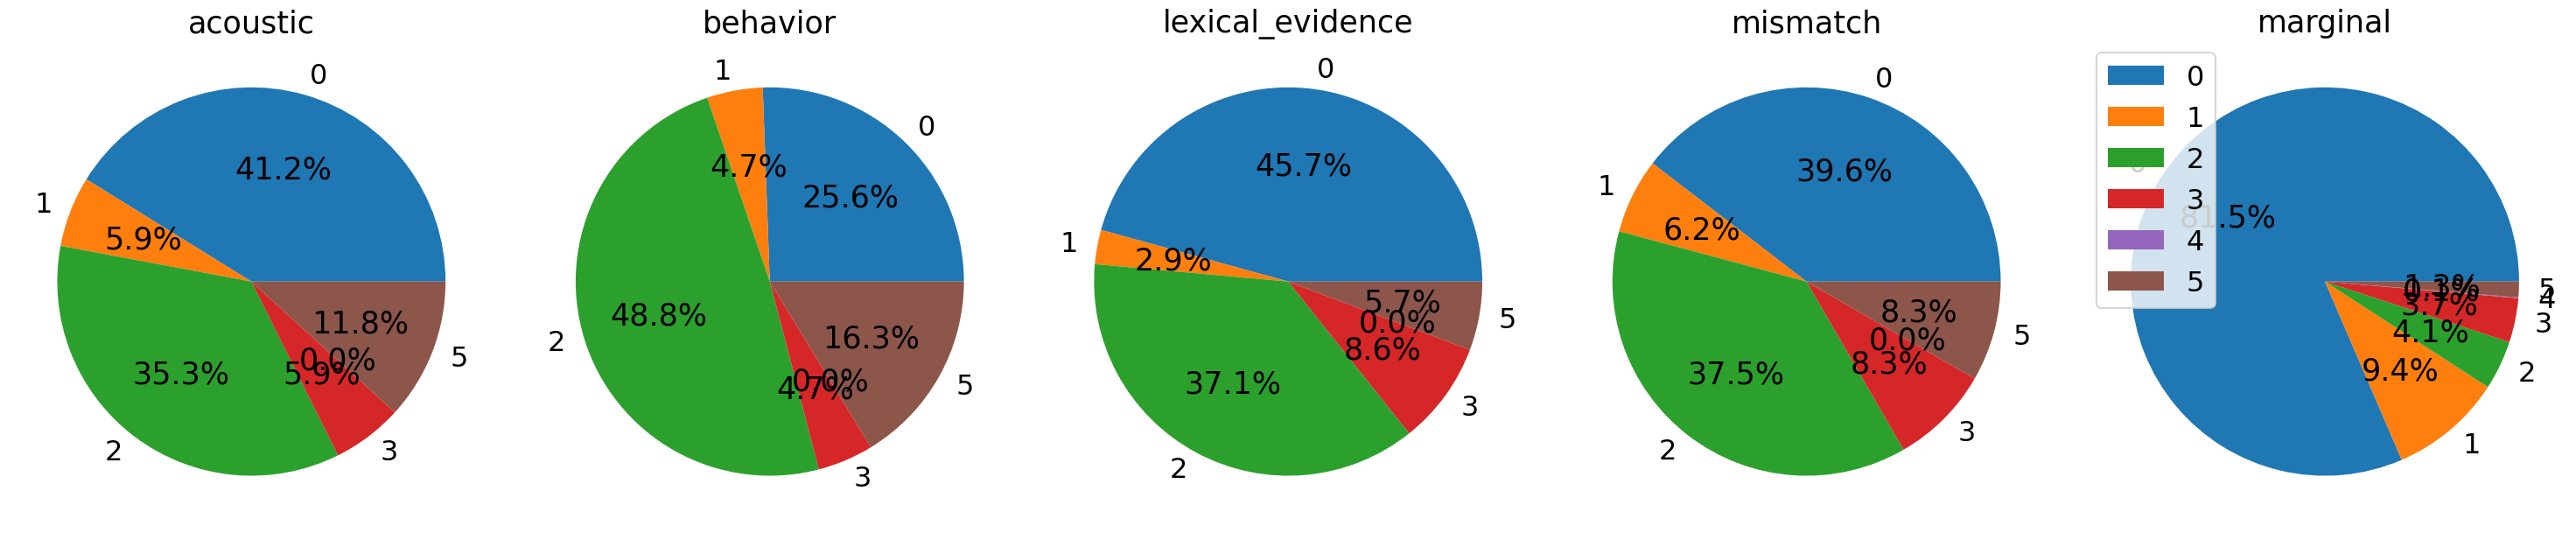

In [18]:
pie = chi2_df.plot.pie(subplots=True, figsize=(30, 20), autopct='%1.1f%%')

for ax in pie:
    ax.set_title(ax.get_yaxis().get_label().get_text())
    ax.get_yaxis().get_label().set_text("")
for ax in pie[:-1]:
    ax.get_legend().remove()
plt.tight_layout()

In [19]:
chi2_contingency(chi2_df)

Chi2ContingencyResult(statistic=367.952544777106, pvalue=8.807850208649809e-66, dof=20, expected_freq=array([[1.32594417e+01, 3.35385878e+01, 2.72988506e+01, 3.74384236e+01,
        1.31346470e+03],
       [1.53530378e+00, 3.88341544e+00, 3.16091954e+00, 4.33497537e+00,
        1.52085386e+02],
       [1.18171866e+00, 2.98905309e+00, 2.43295019e+00, 3.33661741e+00,
        1.17059661e+02],
       [6.69950739e-01, 1.69458128e+00, 1.37931034e+00, 1.89162562e+00,
        6.63645320e+01],
       [9.30487137e-03, 2.35358511e-02, 1.91570881e-02, 2.62725780e-02,
        9.21729611e-01],
       [3.44280241e-01, 8.70826492e-01, 7.08812261e-01, 9.72085386e-01,
        3.41039956e+01]]))

In [28]:
speech_responsive_marginal = pd.merge(speech_responsive_electrodes.loc[speech_responsive_electrodes.index.get_level_values("subject").isin(cluster_df.index.get_level_values("subject"))],
                                      cluster_df,
                                      left_index=True, right_index=True, how="left") \
    .dropna().reset_index().cluster.astype(int).value_counts().reindex(list(range(n_clusters))) \
    .fillna(0).astype(int).rename("speech_responsive_marginal")

chi2_speech_responsive_df = pd.concat([cluster_counts, speech_responsive_marginal], axis=1)
chi2_speech_responsive_df = chi2_speech_responsive_df.loc[chi2_speech_responsive_df.sum(axis=1) > 0]
chi2_speech_responsive_df

,acoustic,behavior,lexical_evidence,mismatch,speech_responsive_marginal
cluster,,,,,
0,7,11,16,19,682
1,1,2,1,3,91
2,6,21,13,18,21
3,1,2,3,4,27
5,2,7,2,4,11


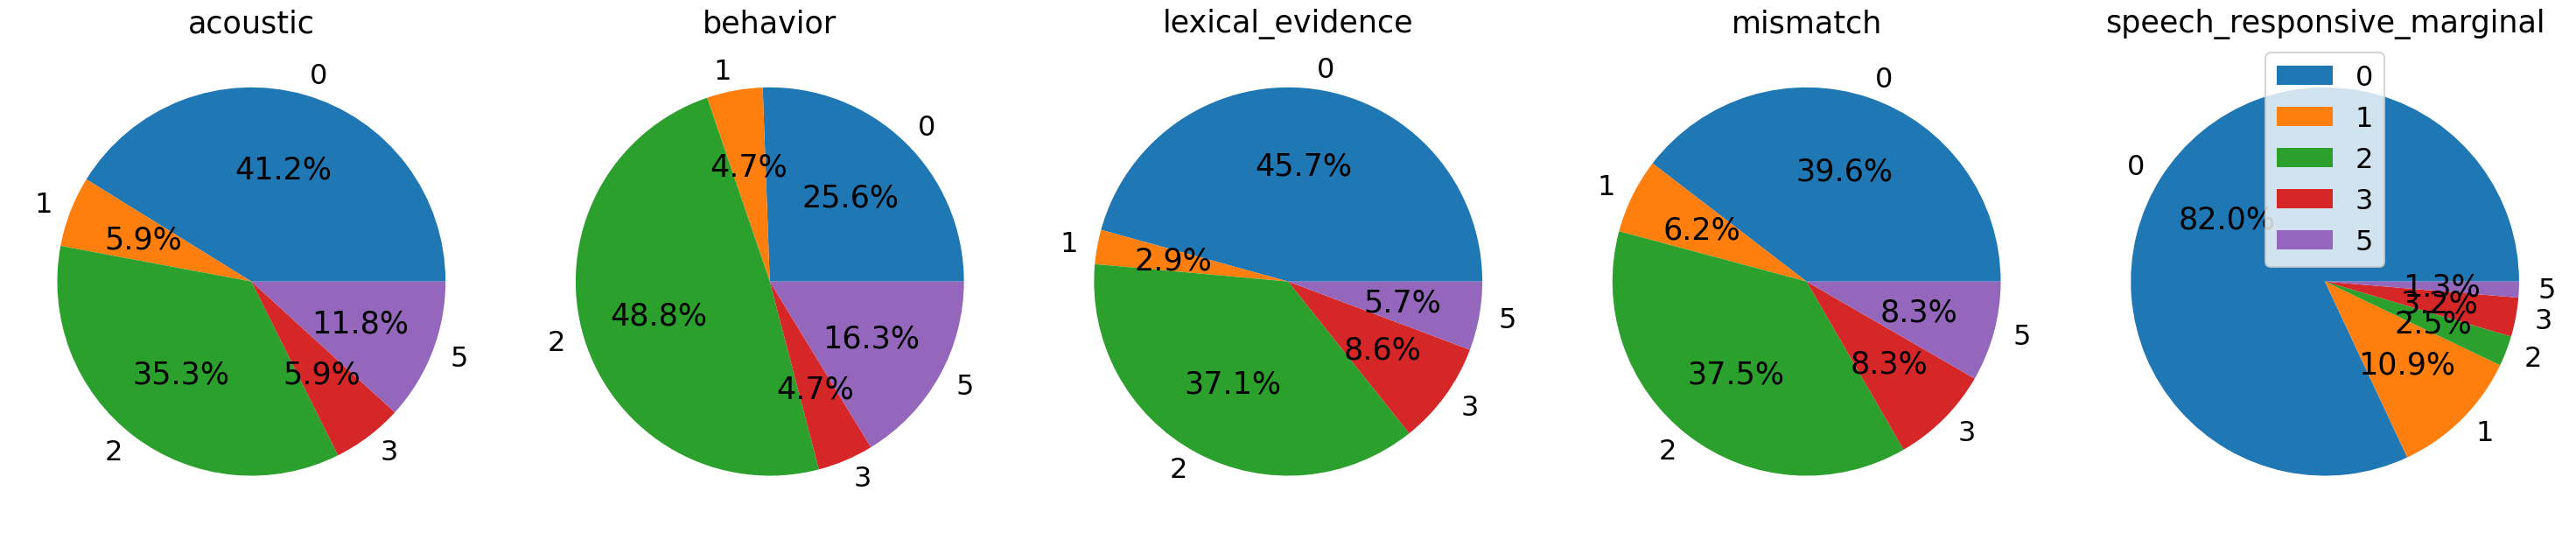

In [29]:
pie = chi2_speech_responsive_df.plot.pie(subplots=True, figsize=(30, 20), autopct='%1.1f%%')

for ax in pie:
    ax.set_title(ax.get_yaxis().get_label().get_text())
    ax.get_yaxis().get_label().set_text("")
for ax in pie[:-1]:
    ax.get_legend().remove()
plt.tight_layout()

In [30]:
chi2_contingency(chi2_speech_responsive_df)

Chi2ContingencyResult(statistic=315.10552854549144, pvalue=1.8830443037341492e-57, dof=16, expected_freq=array([[1.28153846e+01, 3.24153846e+01, 2.63846154e+01, 3.61846154e+01,
        6.27200000e+02],
       [1.70871795e+00, 4.32205128e+00, 3.51794872e+00, 4.82461538e+00,
        8.36266667e+01],
       [1.37743590e+00, 3.48410256e+00, 2.83589744e+00, 3.88923077e+00,
        6.74133333e+01],
       [6.45128205e-01, 1.63179487e+00, 1.32820513e+00, 1.82153846e+00,
        3.15733333e+01],
       [4.53333333e-01, 1.14666667e+00, 9.33333333e-01, 1.28000000e+00,
        2.21866667e+01]]))

<Axes: ylabel='cluster'>

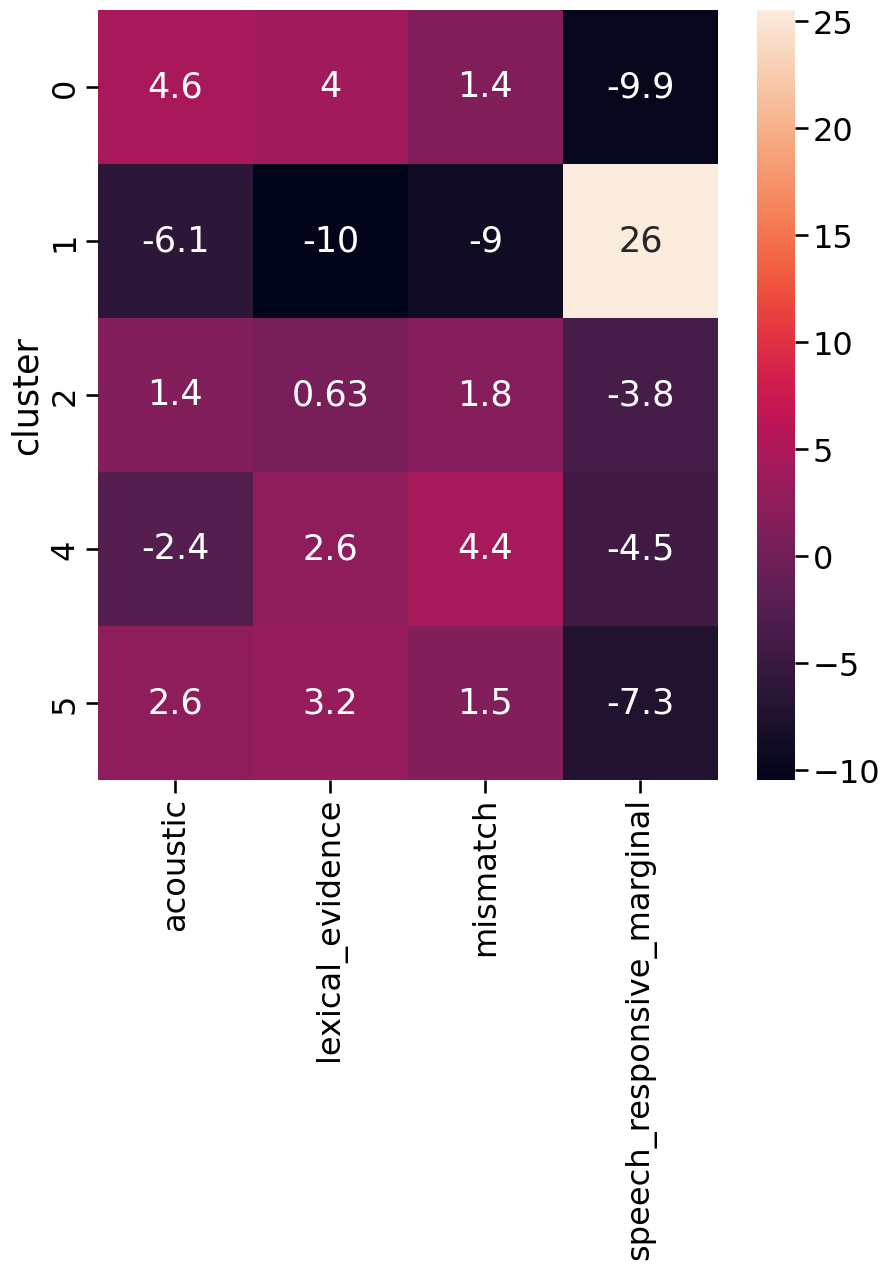

In [143]:
f, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(chi2_speech_responsive_df - chi2_contingency(chi2_speech_responsive_df).expected_freq,
            annot=True)